# Exploratory Data Analysis (EDA)
## Census Income Classification and Customer Segmentation Project

This notebook performs exploratory data analysis on the census income dataset for two business objectives:

1. Build a classification model to predict whether a person earns more than \$50,000.
2. Develop a segmentation model to identify meaningful customer groups for marketing purposes.

This notebook is designed for analysis only. It does not modify the original raw data files. All exploratory work is performed on a copied dataframe derived from the raw input.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Raw Data

The raw dataset is stored in two files:

- `census-bureau.data`: comma-separated raw observations
- `census-bureau.columns`: column names

The raw files are loaded directly and are not overwritten.  
A copied dataframe named `df_eda` is created for exploratory analysis.

In [6]:
import os
print(os.getcwd())

c:\Users\roxan\Downloads\TakeHomeProject\notebooks


In [7]:
DATA_PATH = "../data/census-bureau.data"
COLUMNS_PATH = "../data/census-bureau.columns"

with open(COLUMNS_PATH, "r") as f:
    columns = [line.strip() for line in f.readlines()]

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=columns,
    sep=",",
    skipinitialspace=True
)

# Copy for EDA only; original raw dataframe remains unchanged
df_eda = df.copy()

print("Raw dataset shape:", df.shape)
print("EDA dataframe shape:", df_eda.shape)
df_eda.head()

Raw dataset shape: (199523, 42)
EDA dataframe shape: (199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


## 2. Basic Data Overview

This section inspects the overall size, data types, and basic completeness of the dataset.  
Understanding the structure of the data is important before making modeling decisions, especially because this dataset contains a mixture of numeric variables, coded variables, and high-cardinality categorical variables.

In [8]:
print("Number of rows and columns:", df_eda.shape)
print("\nData types:")
print(df_eda.dtypes)

print("\nFirst 10 columns:")
print(df_eda.columns[:10].tolist())

Number of rows and columns: (199523, 42)

Data types:
age                                             int64
class of worker                                   str
detailed industry recode                        int64
detailed occupation recode                      int64
education                                         str
wage per hour                                   int64
enroll in edu inst last wk                        str
marital stat                                      str
major industry code                               str
major occupation code                             str
race                                              str
hispanic origin                                   str
sex                                               str
member of a labor union                           str
reason for unemployment                           str
full or part time employment stat                 str
capital gains                                   int64
capital losses              

In [9]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  str    
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  str    
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  str    
 7   marital stat                                199523 non-null  str    
 8   major industry code                         199523 non-null  str    
 9   major occupation code                       199523 non-null  str    
 10  race   

## 3. Missing Values and Special Categories

The dataset does not appear to use standard missing values (`NaN`) extensively.  
However, it contains several special text values such as `"Not in universe"`, which may represent inapplicability rather than true missingness.

For this project, these values are preserved during EDA because they may contain meaningful structural information about the population and should not automatically be treated as null values.

In [10]:
missing_summary = df_eda.isnull().sum().sort_values(ascending=False)
missing_summary.head(10)

hispanic origin               874
age                             0
detailed industry recode        0
detailed occupation recode      0
education                       0
wage per hour                   0
enroll in edu inst last wk      0
marital stat                    0
major industry code             0
class of worker                 0
dtype: int64

In [11]:
special_patterns = ["Not in universe", "Not in universe or children", "Children"]

special_summary = {}

for col in df_eda.select_dtypes(include="object").columns:
    values = df_eda[col].unique()
    matched = [v for v in values if any(p in str(v) for p in special_patterns)]
    
    if matched:
        special_summary[col] = matched

special_summary

{'class of worker': ['Not in universe'],
 'education': ['Children'],
 'enroll in edu inst last wk': ['Not in universe'],
 'major industry code': ['Not in universe or children'],
 'major occupation code': ['Not in universe'],
 'member of a labor union': ['Not in universe'],
 'reason for unemployment': ['Not in universe'],
 'full or part time employment stat': ['Children or Armed Forces'],
 'region of previous residence': ['Not in universe'],
 'state of previous residence': ['Not in universe'],
 'migration code-change in msa': ['Not in universe'],
 'migration code-change in reg': ['Not in universe'],
 'migration code-move within reg': ['Not in universe'],
 'live in this house 1 year ago': ['Not in universe under 1 year old'],
 'migration prev res in sunbelt': ['Not in universe'],
 'family members under 18': ['Not in universe'],
 "fill inc questionnaire for veteran's admin": ['Not in universe']}

In [12]:
special_value = "Not in universe"

ratio_summary = {}

for col in df_eda.select_dtypes(include="object").columns:
    ratio = (df_eda[col] == special_value).mean()
    if ratio > 0:
        ratio_summary[col] = ratio

pd.Series(ratio_summary).sort_values(ascending=False).head(10)

fill inc questionnaire for veteran's admin    0.990056
reason for unemployment                       0.969577
enroll in edu inst last wk                    0.936950
region of previous residence                  0.920946
state of previous residence                   0.920946
member of a labor union                       0.904452
family members under 18                       0.722884
major occupation code                         0.504624
class of worker                               0.502423
migration prev res in sunbelt                 0.421275
dtype: float64

## Missing Values and Special Categories

The dataset contains very few standard missing values (NaN), indicating that most fields are populated.

However, several non-standard categorical values are observed across multiple features, including:

- "Not in universe"
- "Not in universe or children"
- "Children"

These values occur frequently and, in some variables, represent a large proportion of the dataset. This suggests that many features are not universally applicable to all individuals.

Importantly, these values do not represent missing data in the traditional sense. Instead, they indicate that a particular attribute does not apply to a given individual. For example, employment-related variables may not apply to children or individuals who are not part of the labor force.

Therefore, these values are retained as valid categories rather than being removed or imputed. Removing them would eliminate meaningful distinctions between population groups.

From a modeling perspective, these categories are likely to be informative. They can help distinguish between different segments of the population, such as individuals who are economically active versus those who are not.

In addition, some variables contain an extremely high proportion of these values, which may limit their usefulness for modeling. These features will be further evaluated during the preprocessing stage.

## 4. Target Variable Inspection

The target variable is the income label.  
Before building a classifier, it is important to verify its format and class balance.

In [13]:
df_eda["label"].value_counts(dropna=False)

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [14]:
label_dist = df_eda["label"].value_counts(normalize=True).sort_index()
label_dist

label
- 50000.    0.937942
50000+.     0.062058
Name: proportion, dtype: float64

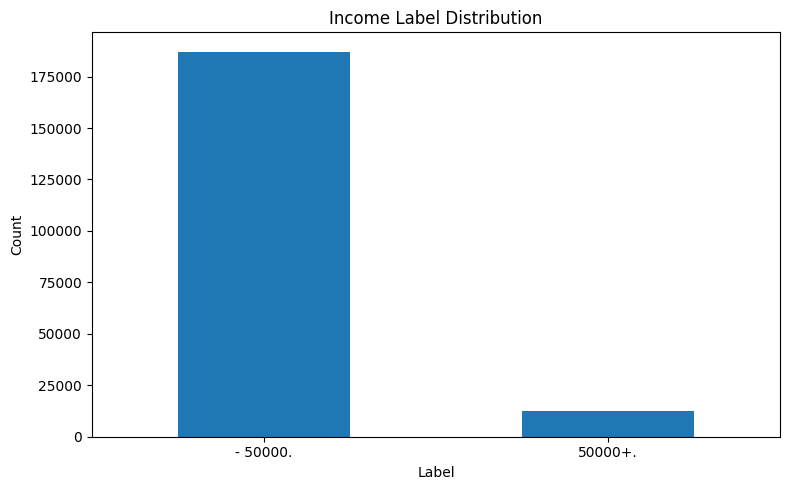

In [15]:
plt.figure(figsize=(8, 5))
df_eda["label"].value_counts().plot(kind="bar")
plt.title("Income Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### EDA interpretation

The target label is imbalanced, with the lower-income group representing the majority of observations (93.79%).  
This is an important modeling consideration because a classifier trained on this dataset may otherwise become biased toward predicting the majority class.

For this reason, model evaluation in later stages should not rely on accuracy alone. Metrics such as precision, recall, F1-score, and ROC-AUC will provide a more balanced assessment of classification performance.

## 5. Binary Target Mapping for Analysis

To support comparative EDA, a binary target variable is created in the copied dataframe only:

- `0` = income less than or equal to \$50,000
- `1` = income greater than \$50,000

This mapping is created only for analysis convenience and does not alter the raw input files.

In [16]:
df_eda["label_binary"] = df_eda["label"].apply(
    lambda x: 1 if "50000+" in str(x) else 0
)

df_eda["label_binary"].value_counts()

label_binary
0    187141
1     12382
Name: count, dtype: int64

## 6. Numeric and Categorical Feature Review


The dataset contains both numeric and categorical variables. However, not all numeric-looking variables represent continuous measurements.

Several variables are stored as integers but are in fact coded categorical variables (such as industry and occupation recodes). These variables represent discrete categories rather than continuous quantities and should therefore be treated as categorical features.

After reviewing the dataset, features are categorized into:

- True numeric variables: continuous or count-based features (e.g., age, wage per hour, capital gains)
- Categorical variables: string-based features and integer-coded categorical variables

This distinction is important because numeric and categorical variables require different preprocessing techniques and have different implications for both classification and segmentation models.

In [17]:
# Step 1: initial split
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_eda.select_dtypes(include=["object"]).columns.tolist()

# Step 2: manually fix coded categorical variables
coded_categorical = [
    "detailed industry recode",
    "detailed occupation recode",
    "major industry code",
    "major occupation code",
    "own business or self employed",
    "veterans benefits",
    "label_binary",
    "year"
]

# Move them to categorical
numeric_cols = [col for col in numeric_cols if col not in coded_categorical]
categorical_cols = categorical_cols + coded_categorical

print("Final numeric columns:", len(numeric_cols))
print("Final categorical columns:", len(categorical_cols))

Final numeric columns: 8
Final categorical columns: 37


## 7. Numeric Feature Summary

The numeric variables exhibit substantial variation in scale and distribution.

In particular, variables such as `capital gains`, `capital losses`, and `dividends from stocks` are highly skewed, with a large proportion of zero values and a small number of extreme observations. These variables are likely to carry strong predictive signal for income, but their skewness suggests that models robust to outliers or appropriate transformations may be beneficial.

Additionally, some integer-valued variables initially appear numeric but are actually encoded categorical variables. These variables should not be treated as continuous features, as their numerical values do not represent meaningful distances.

Overall, the dataset contains a mixture of continuous variables, count-based variables, and encoded categorical variables. This requires careful preprocessing, as different feature types must be handled differently in both classification and segmentation models.

In [18]:
df_eda[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0
wage per hour,199523.0,55.426908,274.896454,0.00,0.000,0.00,0.00,9999.0
capital gains,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0
capital losses,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0
dividends from stocks,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0
weight,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3
num persons worked for employer,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0
weeks worked in year,199523.0,23.174897,24.411488,0.00,0.000,8.00,52.00,52.0


### EDA interpretation

The numeric features vary substantially in scale.  
For example, variables such as `capital gains`, `capital losses`, and `dividends from stocks` are highly skewed, with many zero values and a small number of large observations. This suggests that income-related financial variables may contain strong predictive signal but may also require robust preprocessing during modeling.

In addition, some integer-valued variables appear to be coded categories rather than naturally continuous features. This should be considered during feature engineering and segmentation design.

Some numeric variables (e.g., capital gains, dividends from stocks) contain extreme maximum values, which may indicate capped or top-coded values in the original dataset. This should be considered during preprocessing.

## 8. Selected Numeric Variables and Their Relationship with Income

A few variables are especially relevant for understanding income differences, such as:

- age
- wage per hour
- capital gains
- capital losses
- dividends from stocks
- weeks worked in year
- num persons worked for employer
- weight

These variables are reviewed individually to understand whether higher-income individuals display systematic patterns.

Because this dataset includes a sampling weight, weighted averages are used when comparing income groups. In addition, some variables such as `wage per hour` are highly skewed and contain a large proportion of zero values, so both average values and non-zero rates are examined.

In [19]:
key_numeric_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weeks worked in year",
    "num persons worked for employer",
    "weight"
]

existing_key_numeric_cols = [col for col in key_numeric_cols if col in df_eda.columns]

print("Selected numeric variables:")
print(existing_key_numeric_cols)

Selected numeric variables:
['age', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'weeks worked in year', 'num persons worked for employer', 'weight']


In [20]:
def weighted_mean(x, weights):
    return (x * weights).sum() / weights.sum()

grouped = df_eda.groupby("label_binary")

weighted_summary = pd.DataFrame({
    col: grouped.apply(lambda g: weighted_mean(g[col], g["weight"]))
    for col in existing_key_numeric_cols if col != "weight"
}).T

weighted_summary.columns = ["Income <= 50K", "Income > 50K"]
weighted_summary

,Income <= 50K,Income > 50K
age,33.676008,46.129831
wage per hour,55.723077,81.373316
capital gains,144.574620,4781.242068
capital losses,27.872649,194.792756
dividends from stocks,109.484703,1483.940367
weeks worked in year,21.900271,48.163953
num persons worked for employer,1.876119,4.028065


In [21]:
# Wage-specific check
wage_nonzero_by_income = df_eda.groupby("label_binary").apply(
    lambda g: (g["wage per hour"] > 0).mean()
)

wage_nonzero_by_income.index = ["Income <= 50K", "Income > 50K"]
print("Proportion with non-zero wage per hour by income group:")
print(wage_nonzero_by_income)

Proportion with non-zero wage per hour by income group:
Income <= 50K    0.057433
Income > 50K     0.044904
dtype: float64


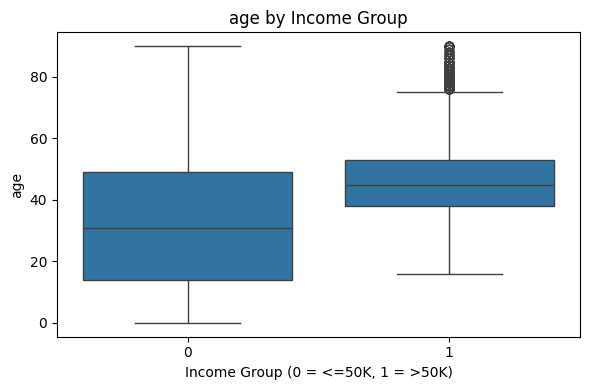

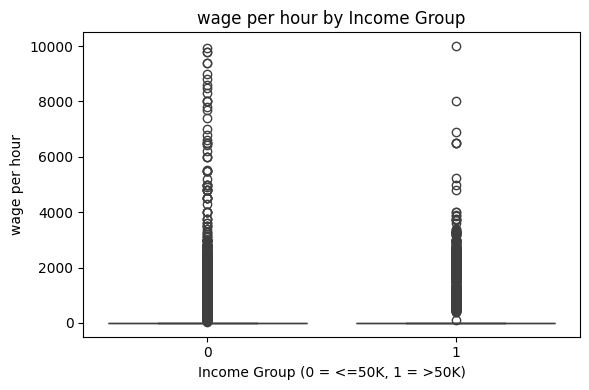

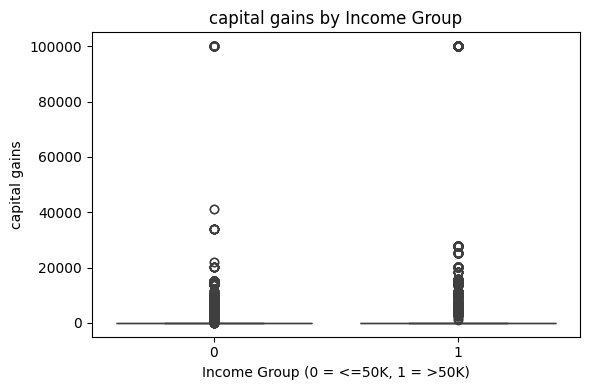

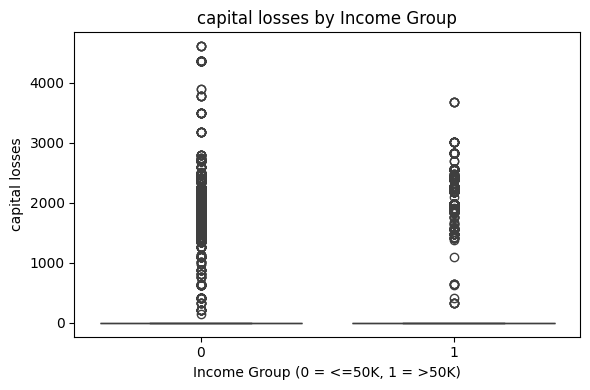

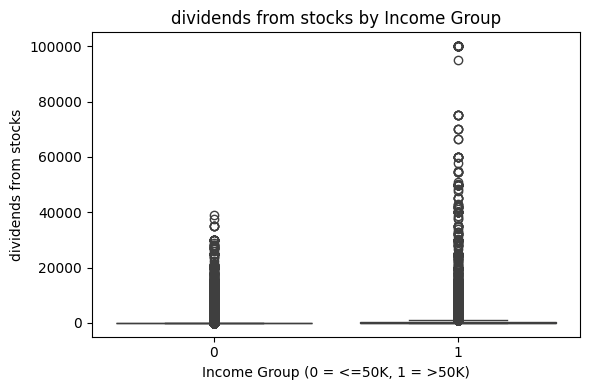

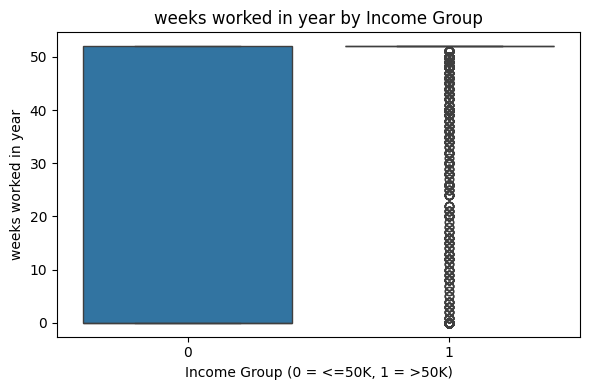

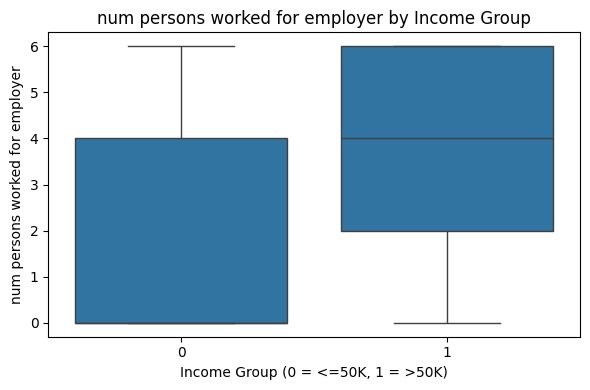

In [23]:
# Boxplots for selected numeric variables
# Skip 'weight' because it is a survey/sample weight rather than a behavioral feature
import matplotlib.pyplot as plt
import seaborn as sns

for col in existing_key_numeric_cols:
    if col == "weight":
        continue

    plt.figure(figsize=(6, 4))
    sns.boxplot(x="label_binary", y=col, data=df_eda)
    plt.title(f"{col} by Income Group")
    plt.xlabel("Income Group (0 = <=50K, 1 = >50K)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### EDA interpretation

The higher-income group tends to differ from the lower-income group on several economically meaningful variables.  
In particular, variables such as `capital gains`, `dividends from stocks`, and `weeks worked in year` are expected to show stronger separation between the two classes. These patterns are consistent with the business objective, since individuals with higher earnings often also display higher levels of labor market engagement and investment-related income.

These findings suggest that both labor-force variables and financial variables are likely to be important for classification.

## 9. Categorical Feature Exploration


Many business-relevant characteristics in the dataset are categorical, including education, marital status, occupation, citizenship, and sex.

These variables are especially important for both classification and segmentation because they directly describe socio-economic attributes.

This section first reviews the most frequent categories for selected high-value variables, and then examines how these categories differ across income groups.

In [24]:
selected_categorical_cols = [
    "class of worker",
    "education",
    "marital stat",
    "major industry code",
    "major occupation code",
    "race",
    "sex",
    "citizenship",
    "full or part time employment stat",
    "tax filer stat"
]

selected_categorical_cols = [col for col in selected_categorical_cols if col in df_eda.columns]

for col in selected_categorical_cols:
    print(f"\nTop categories for: {col}")
    print(df_eda[col].value_counts().head(10))


Top categories for: class of worker
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

Top categories for: education
education
High school graduate                      48407
Children                                  47422
Some college but no degree                27820
Bachelors degree(BA AB BS)                19865
7th and 8th grade                          8007
10th grade                                 7557
11th grade                                 6876
Masters degree(MA MS MEng MEd MSW MBA)     6541
9th grade                                  6230
Associates degree-occup /vocational        5358
Name: count, dtype: int64

Top 

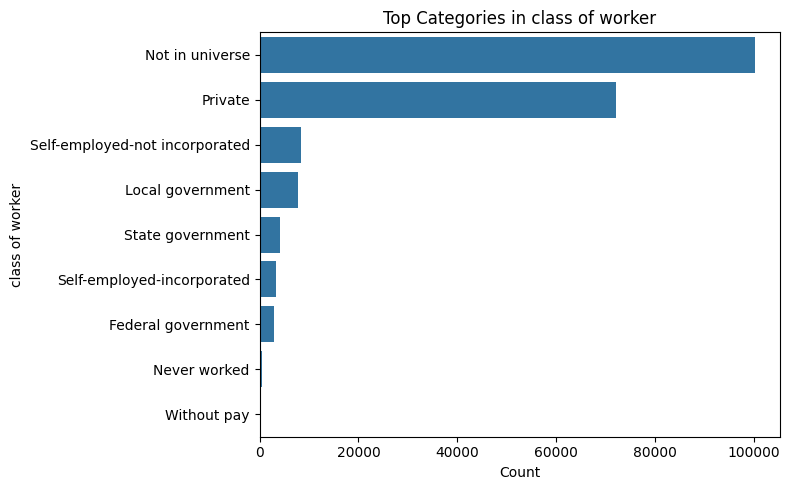

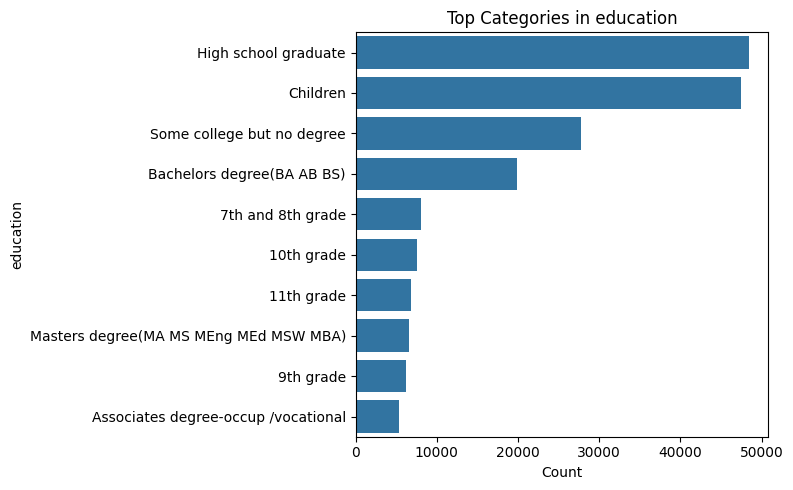

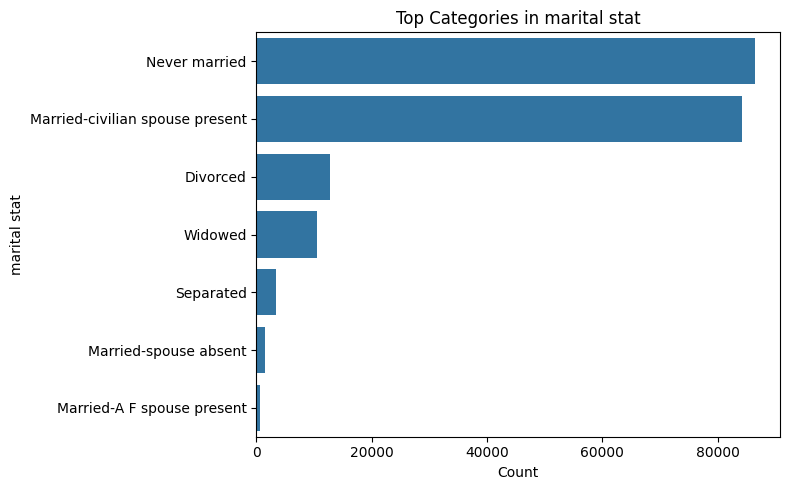

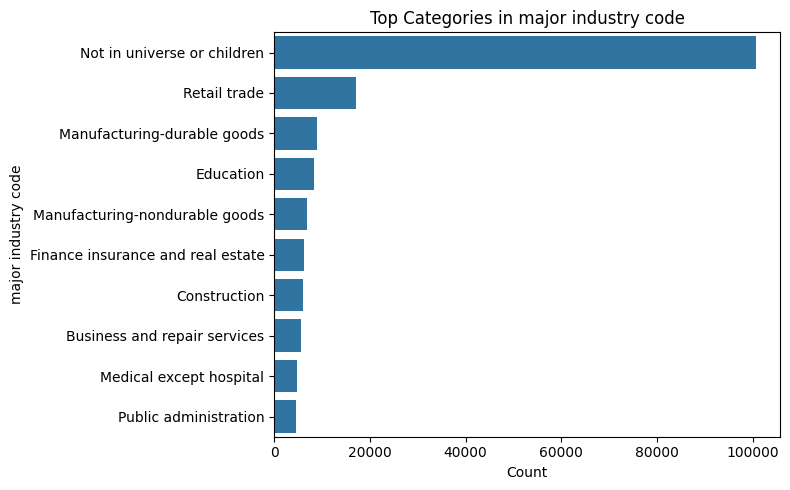

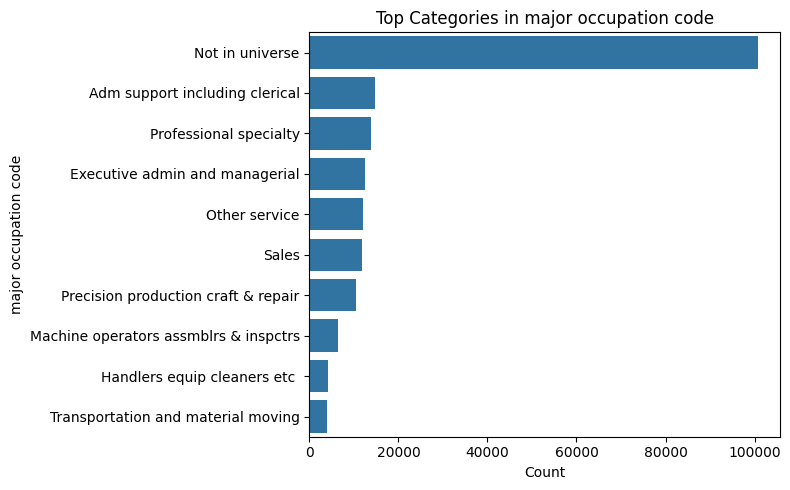

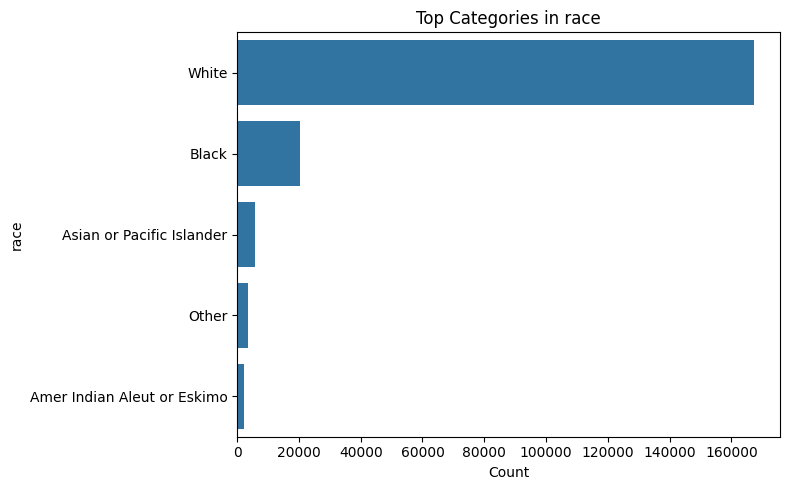

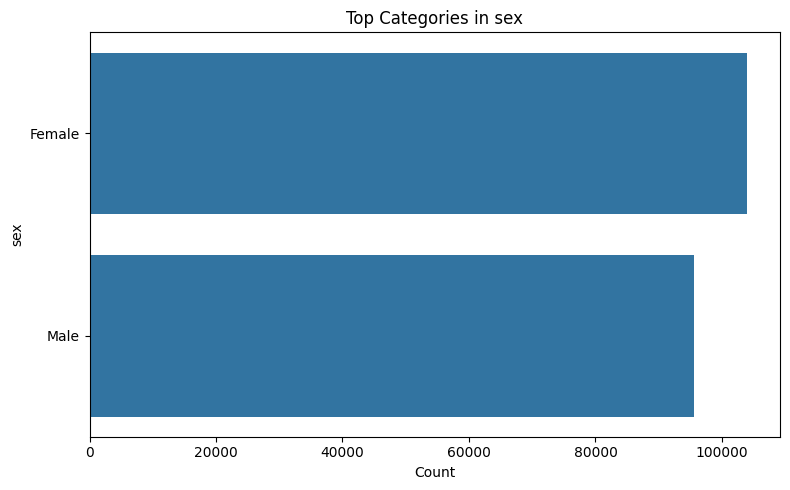

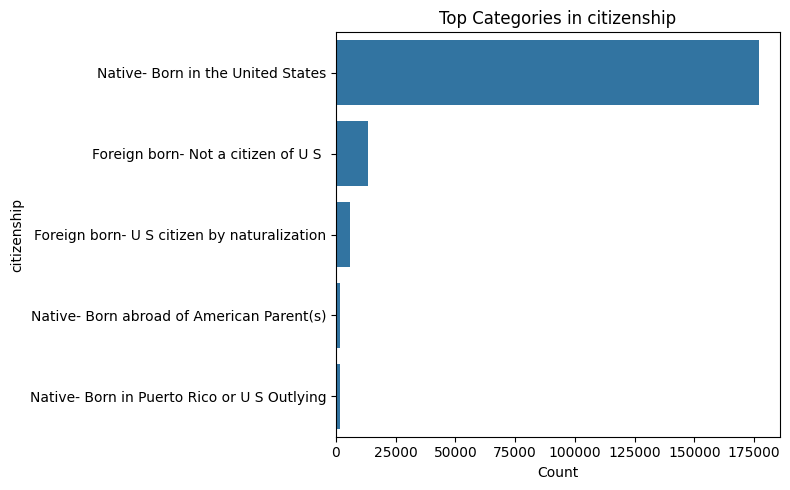

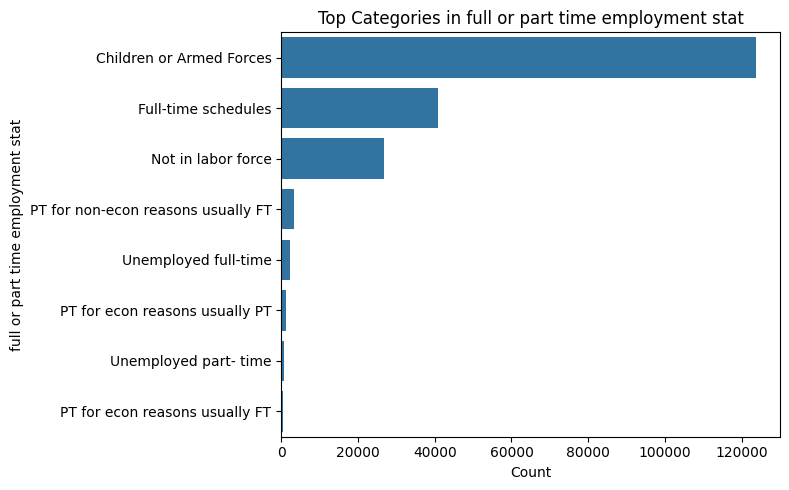

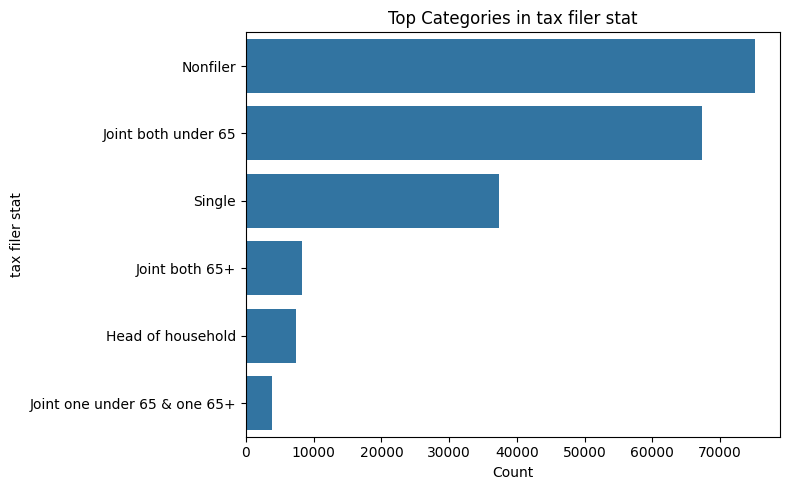

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in selected_categorical_cols:
    top_categories = df_eda[col].value_counts().head(10).index

    plt.figure(figsize=(8,5))

    sns.countplot(
        y=col,
        data=df_eda[df_eda[col].isin(top_categories)],
        order=top_categories
    )

    plt.title(f"Top Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 10. High-Income Rate by Category


To better understand which population groups are associated with higher income, the analysis computes the proportion of individuals with income above $50,000 within each category.

Unlike raw frequency counts, this measure reflects conditional probability (P(high income | category)), which is more informative for both prediction and marketing segmentation.

Because the dataset is based on weighted survey sampling, weighted estimates are used to better reflect the underlying population.

In [35]:
def weighted_high_income_rate_table(df_input, column, top_n=10):
    top_categories = df_input[column].value_counts().head(top_n).index
    temp = df_input[df_input[column].isin(top_categories)].copy()

    summary = temp.groupby(column).apply(
        lambda g: pd.Series({
            "high_income_rate": (g["label_binary"] * g["weight"]).sum() / g["weight"].sum(),
            "count": g.shape[0]
        })
    )

    summary = summary.sort_values("high_income_rate", ascending=False)
    return summary

for col in selected_categorical_cols:
    print(f"\nWeighted high-income rate for: {col}")
    display(weighted_high_income_rate_table(df_eda, col))


Weighted high-income rate for: class of worker


,high_income_rate,count
class of worker,,
Self-employed-incorporated,0.362642,3265.0
Federal government,0.210753,2925.0
Self-employed-not incorporated,0.132921,8445.0
State government,0.117224,4227.0
Local government,0.112191,7784.0
Private,0.102234,72028.0
Not in universe,0.009402,100245.0
Never worked,0.002939,439.0
Without pay,0.001849,165.0



Weighted high-income rate for: education


,high_income_rate,count
education,,
Masters degree(MA MS MEng MEd MSW MBA),0.315950,6541.0
Bachelors degree(BA AB BS),0.203474,19865.0
Associates degree-occup /vocational,0.075936,5358.0
Some college but no degree,0.064957,27820.0
High school graduate,0.037622,48407.0
11th grade,0.010311,6876.0
7th and 8th grade,0.008839,8007.0
10th grade,0.008342,7557.0
9th grade,0.005961,6230.0



Weighted high-income rate for: marital stat


...

,high_income_rate,count
citizenship,,
Foreign born- U S citizen by naturalization,0.104552,5855.0
Native- Born abroad of American Parent(s),0.076403,1756.0
Native- Born in the United States,0.064679,176992.0
Foreign born- Not a citizen of U S,0.038855,13401.0
Native- Born in Puerto Rico or U S Outlying,0.020078,1519.0



Weighted high-income rate for: full or part time employment stat


,high_income_rate,count
full or part time employment stat,,
Full-time schedules,0.133330,40736.0
PT for econ reasons usually PT,0.129689,1209.0
PT for non-econ reasons usually FT,0.115320,3322.0
PT for econ reasons usually FT,0.066084,525.0
Children or Armed Forces,0.049472,123769.0
Unemployed full-time,0.033754,2311.0
Unemployed part- time,0.021033,843.0
Not in labor force,0.017379,26808.0



Weighted high-income rate for: tax filer stat


,high_income_rate,count
tax filer stat,,
Joint both under 65,0.137532,67383.0
Joint one under 65 & one 65+,0.081449,3867.0
Head of household,0.060355,7426.0
Single,0.059625,37421.0
Joint both 65+,0.055546,8332.0
Nonfiler,0.000441,75094.0


### EDA Interpretation

The categorical analysis reveals strong and structured differences in income across multiple socio-economic dimensions.

Education level shows a clear gradient effect. Individuals with advanced degrees (e.g., Master's: ~31.6%, Bachelor's: ~20.3%) have substantially higher probabilities of earning above $50K compared to those with lower education levels (e.g., high school: ~3.7%, children: ~0%). This suggests that education is one of the strongest predictors of income.

Occupation and industry also exhibit significant variation. High-income rates are concentrated in executive and professional roles (e.g., executive/managerial: ~29%, professional specialty: ~25%), while service and manual occupations show much lower rates. This reflects structural differences in earning potential across job types.

Employment status further reinforces this pattern. Individuals working full-time have notably higher income rates (~13.3%) compared to those not in the labor force (~1.7%) or unemployed. This indicates that labor force participation is a key driver of income.

Marital status also shows meaningful differences. Married individuals, particularly those with a spouse present, tend to have higher income probabilities (~11.9%) compared to never-married individuals (~1.4%), which may reflect household-level economic advantages.

In addition, gender differences are substantial. Male individuals have a significantly higher high-income rate (~10.3%) compared to females (~2.6%), indicating potential structural or labor market disparities.

From a business perspective, these categorical variables are highly valuable because they are interpretable and actionable. They can be directly used to define customer segments, such as high-income professionals, emerging middle-income groups, or low-income/non-participating populations.

Overall, categorical variables capture critical structural differences in economic status and are expected to play a dominant role in both classification and segmentation models.

## 11. Correlation Review for Numeric Variables

Although the dataset is dominated by categorical variables, reviewing the relationships among numeric variables can help identify redundancy or overlapping signals.

This is useful for understanding whether certain features may carry similar information before model development.

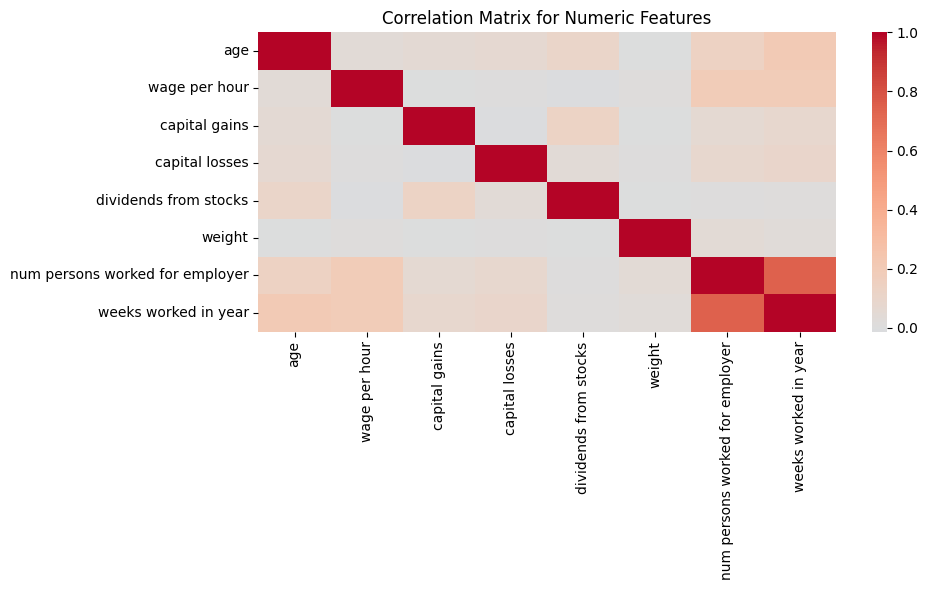

In [36]:
corr = df_eda[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Numeric Features")
plt.tight_layout()
plt.show()

### EDA Interpretation

The correlation analysis indicates that most numeric variables are weakly to moderately correlated, suggesting that they capture different aspects of individual economic behavior rather than redundant information.

A notable exception is the relationship between `weeks worked in year` and `num persons worked for employer`, which shows a relatively stronger positive correlation. This is expected, as both variables reflect labor market participation and employment intensity.

In contrast, financial variables such as `capital gains`, `capital losses`, and `dividends from stocks` exhibit very low correlations with other features. This suggests that investment-related income is largely independent of standard employment characteristics and may provide unique predictive signal.

Additionally, the `weight` variable shows minimal correlation with other features, confirming that it functions as a sampling adjustment factor rather than a behavioral or economic attribute.

Overall, the low level of multicollinearity indicates that most numeric variables contribute complementary information, and feature redundancy is not a major concern at this stage. However, conceptually related variables (e.g., employment-related features) should still be monitored during modeling.

## 12. Review of the Sampling Weight

The dataset includes a `weight` variable, which reflects the relative importance of each observation in representing the underlying population.

This is a key characteristic of survey-based datasets, where observations are not sampled uniformly.

Understanding this variable is important because it affects how statistical summaries and model training should be conducted.

count    199523.000000
mean       1740.380269
std         993.768156
min          37.870000
25%        1061.615000
50%        1618.310000
75%        2188.610000
max       18656.300000
Name: weight, dtype: float64


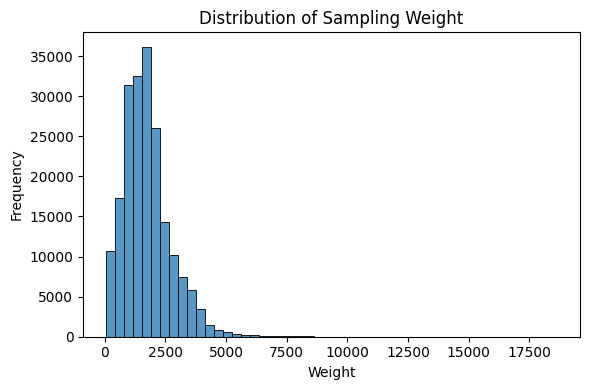

In [37]:
if "weight" in df_eda.columns:
    print(df_eda["weight"].describe())

    plt.figure(figsize=(6, 4))
    sns.histplot(df_eda["weight"], bins=50)
    plt.title("Distribution of Sampling Weight")
    plt.xlabel("Weight")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### EDA Interpretation

The sampling weight varies substantially across observations, with values ranging from approximately 38 to over 18,000. This large spread indicates that different records represent very different portions of the underlying population.

This pattern is consistent with stratified survey sampling, where certain population groups are oversampled or undersampled, and weights are used to correct for this imbalance.

As a result, treating all observations equally would distort population-level estimates and potentially bias model outcomes toward overrepresented groups.

Therefore, the weight variable should be incorporated into statistical analysis and model training as a sample weight. This ensures that both descriptive statistics and predictive models better reflect the true population distribution.

It is also important to note that the weight variable does not represent a behavioral or economic attribute of individuals. Instead, it functions as a scaling factor and should not be interpreted as a predictive feature itself.

## 13. EDA Implications for Segmentation

Not all variables are equally suitable for segmentation. Effective segmentation should rely on variables that are interpretable, behaviorally meaningful, and relevant to marketing decisions.

Based on the EDA, several variables show strong differentiation across population groups and are therefore well-suited for segmentation:

- **Age**: captures life stage differences (e.g., early career vs. established workforce)
- **Education**: shows a clear gradient in income potential (e.g., Master's ~31.6% vs. high school ~3.7%)
- **Marital status**: reflects household structure and economic stability
- **Employment status**: distinguishes active labor force participants from non-participants
- **Occupation and industry**: capture structural differences in earning potential (e.g., managerial vs. service roles)
- **Weeks worked in year**: indicates labor intensity and engagement
- **Sex**: shows meaningful differences in income distribution (~10.3% vs. ~2.6%)
- **Citizenship**: reflects demographic and socio-economic variation
- **Financial variables** (capital gains, dividends): identify investment-driven income segments

These variables are particularly valuable because they not only differentiate individuals statistically, but can also be translated into actionable marketing segments (e.g., high-income professionals, part-time workers, or non-participating individuals).

At the same time, the target variable (income label) is excluded from clustering, as segmentation aims to uncover natural groupings rather than reproduce the classification outcome.

## 14. Key EDA Findings

The main findings from the exploratory analysis are as follows:

1. The dataset is dominated by categorical variables, many of which show strong and structured relationships with income. In particular, education, occupation, and employment status demonstrate clear gradients in high-income rates.

2. The target variable is highly imbalanced (approximately 6% high income vs. 94% low income), indicating that model evaluation should rely on metrics beyond accuracy, such as precision, recall, and AUC.

3. Numeric variables related to financial outcomes (capital gains, dividends) and labor participation (weeks worked) show strong differentiation between income groups, although many of these variables are highly skewed with a large proportion of zero values.

4. The dataset contains frequent "Not in universe" categories, which do not represent missing data but instead indicate structural inapplicability. These values provide meaningful information about labor force participation and should be preserved.

5. The sampling weight variable varies significantly across observations (from ~38 to over ~18,000), reflecting stratified survey sampling. This variable is critical for ensuring population-representative analysis and must be incorporated into model training as a sample weight.

6. Correlation among numeric variables is generally low, suggesting that most features provide complementary rather than redundant information.

Overall, the dataset is well-suited for both supervised classification and interpretable segmentation. The combination of strong categorical signals and meaningful numeric features provides a solid foundation for building predictive and segmentation models, provided that class imbalance and sampling weights are properly handled.

### Modeling Implications

From a modeling perspective, categorical variables such as education, occupation, and employment status are expected to provide the strongest predictive signal due to their clear separation across income groups.

Numeric financial variables (e.g., capital gains, dividends) also carry strong signal but require careful handling due to heavy skewness and a large proportion of zero values.

Given these characteristics, tree-based models (e.g., XGBoost) are likely to perform better than linear models without transformation. In addition, the sampling weight should be incorporated as a sample_weight parameter during training to ensure population-representative predictions.
